
# Laboratorio 2 – Complejidad y Búsqueda de Hiperparámetros  
**Curso:** ISIS2611  
**Caso:** AlpesHearth  

**Estudiantes:**  
- Nikol Katherin Rodriguez Ortiz - 202317538
- Daniel Bolivar Bernal - 202310329



## 1. Introducción

En este laboratorio se evalúan diferentes enfoques de modelado para estimar el riesgo cardiovascular:

- Regresión polinomial  
- Regresión regularizada (Ridge y Lasso)  
- Regresión polinomial regularizada  

Se analiza el impacto de la complejidad en la generalización y se estiman intervalos de confianza mediante bootstrapping.


## 2. Carga de Librerías

In [187]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")
%matplotlib inline


## 3. Carga del Dataset

In [188]:
# Cargar el dataset limpio
dataset = pd.read_csv("dataset_limpio.csv")
df =dataset.copy()

df.head()



,Patient ID,Date of Service,Sex,Age,Weight (kg),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),HDL (mg/dL),...,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level,Weight_imputed_median,WHR_imputed_median,TC_missing_original,TC_imputed_median
0,QgsB2968,01 Aug 20,M,40,56.0,16.50,84.20,144/85,155.0,53.0,...,144.0,85.0,Hypertension Stage 1,90.0,13.600,LOW,False,False,False,False
1,GcaU3177,01 Aug 24,M,63,55.0,24.89,103.18,101/77,252.0,42.0,...,101.0,77.0,Normal,180.0,15.069,INTERMEDIARY,False,False,False,False
2,ywdP2642,01 Jan 22,F,58,98.0,28.20,74.60,133/83,281.0,68.0,...,133.0,83.0,Hypertension Stage 1,183.0,17.910,INTERMEDIARY,False,False,False,False
3,FFib5797,01 Jul 20,M,42,108.0,39.50,106.70,103/64,186.0,79.0,...,103.0,82.0,Normal,90.0,18.770,INTERMEDIARY,False,False,False,False
4,ZzGw2657,01 Jun 23,M,45,62.0,19.20,84.10,117/60,141.0,45.0,...,117.0,60.0,Normal,90.0,14.510,INTERMEDIARY,False,False,False,False


In [189]:


# Copia del dataset
df = df.copy()

# Columna que se dejan
cols_modelo2 = [
    'BMI',
    'Systolic BP',
    'Total Cholesterol (mg/dL)',
    'Estimated LDL (mg/dL)',
    'Weight (kg)',
    'Diabetes Status',
    'Blood Pressure Category',
    'CVD Risk Score'
]

df = df[cols_modelo2]

# Variables binarias (Y/N)
binary_cols = [
    'Diabetes Status',
]

for col in binary_cols:
    df[col] = df[col].map({'Y':1, 'N':0})

# Ajustar Blood Pressure Category
df = pd.get_dummies(df, columns=['Blood Pressure Category'], drop_first=True)

print(df.head())
print("\nShape:", df.shape)
print("\nTipos:")
print(df.dtypes)

     BMI  Systolic BP  Total Cholesterol (mg/dL)  Estimated LDL (mg/dL)  \
0  16.50        144.0                      155.0                   90.0   
1  24.89        101.0                      252.0                  180.0   
2  28.20        133.0                      281.0                  183.0   
3  39.50        103.0                      186.0                   90.0   
4  19.20        117.0                      141.0                   90.0   

   Weight (kg)  Diabetes Status  CVD Risk Score  \
0         56.0                0          13.600   
1         55.0                0          15.069   
2         98.0                0          17.910   
3        108.0                1          18.770   
4         62.0                1          14.510   

   Blood Pressure Category_Hypertension Stage 1  \
0                                          True   
1                                         False   
2                                          True   
3                                     

In [190]:
X = df.drop(columns=["CVD Risk Score"])
y = df["CVD Risk Score"]

# Hold-out
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

cv = KFold(n_splits=10, shuffle=True, random_state=42)

## 4. Modelo de Regresión Polinomial

In [191]:
pipe_poly = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(include_bias=False)),
    ("model", LinearRegression())
])

param_poly = {
    "poly__degree": [1,2,3,4,5],
    "scaler": [StandardScaler(), MinMaxScaler()]
}

grid_poly = GridSearchCV(pipe_poly, param_poly, cv=cv, scoring="neg_mean_squared_error")
grid_poly.fit(X_train, y_train)

best_poly = grid_poly.best_estimator_

y_pred = best_poly.predict(X_test)

rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred))
mae_poly = mean_absolute_error(y_test, y_pred)
r2_poly = r2_score(y_test, y_pred)

print(   'RMSE: ' + str(rmse_poly) + " MAE: " + str(mae_poly) + " R2: " + str(r2_poly))

RMSE: 0.6442293907390714 MAE: 0.27952858002979114 R2: 0.9367414289466259


In [192]:
degrees = range(1,6)
means = []
stds = []

from sklearn.model_selection import cross_val_score

for d in degrees:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=d)),
        ("model", LinearRegression())
    ])

    scores = cross_val_score(pipe, X_train, y_train, cv=10, scoring="neg_mean_squared_error")
    scores = -scores
    means.append(scores.mean())
    stds.append(scores.std())

In [193]:
print("Mejores hiperparámetros:", grid_poly.best_params_)
print("Mejor MSE (negativo) en validación cruzada:", -grid_poly.best_score_)

Mejores hiperparámetros: {'poly__degree': 1, 'scaler': StandardScaler()}
Mejor MSE (negativo) en validación cruzada: 0.43937965599562717


In [194]:
best_index = grid_poly.best_index_
best_std = grid_poly.cv_results_['std_test_score'][best_index]
print(f"Desviación estándar del MSE en CV: {best_std:.4f}")

Desviación estándar del MSE en CV: 0.2749


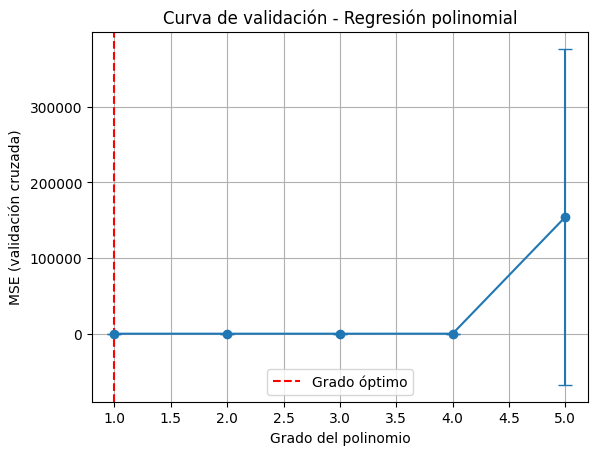

In [195]:
plt.errorbar(degrees, means, yerr=stds, marker="o", capsize=5)
plt.axvline(x=grid_poly.best_params_['poly__degree'], color='r', linestyle='--', label='Grado óptimo')
plt.title("Curva de validación - Regresión polinomial")
plt.xlabel("Grado del polinomio")
plt.ylabel("MSE (validación cruzada)")
plt.legend()
plt.grid(True)
plt.show()

### Análisis del Modelo de Regresión Polinomial

Se construyó un pipeline que incluye escalamiento, generación de características polinomiales y regresión lineal, optimizado mediante GridSearchCV con validación cruzada. Se exploraron grados polinomiales entre 1 y 5 y dos estrategias de escalamiento (StandardScaler y MinMaxScaler).

El mejor modelo encontrado corresponde a un polinomio de grado 1 con StandardScaler, lo que equivale a una regresión lineal simple. Este modelo obtuvo las siguientes métricas en el conjunto de prueba:

**RMSE:** 0.64

**MAE:** 0.27

**R²:** 0.936

Estos resultados indican un ajuste muy bueno, con alta capacidad explicativa y bajo error absoluto promedio.

Al analizar la curva de validación, se observa que el error de validación cruzada aumenta a medida que crece el grado del polinomio, lo cual indica que modelos más complejos no mejoran el desempeño. Además, la desviación estándar del MSE en validación cruzada (≈ 0.27) sugiere cierta variabilidad entre folds, especialmente en modelos de mayor complejidad.

Este comportamiento es un indicio de sobreajuste: al incrementar el grado del polinomio, el modelo gana flexibilidad pero pierde capacidad de generalización. En lugar de capturar patrones reales, comienza a ajustarse al ruido de los datos.

El hecho de que el grado óptimo sea 1 sugiere que la relación entre las variables predictoras y la variable objetivo es aproximadamente lineal. Por lo tanto, añadir términos polinomiales no aporta valor y solo incrementa la complejidad innecesariamente.

En conclusión, el análisis muestra que incrementar la complejidad del modelo no siempre mejora el desempeño, y resalta la importancia de usar validación cruzada para detectar sobreajuste y seleccionar modelos más simples pero robustos.

## 5. Modelos Regularizados (Ridge y Lasso)

In [196]:
pipe_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

param_ridge = {
    "model__alpha": np.logspace(-3, 3, 50),
    "scaler": [StandardScaler(), MinMaxScaler()]
}

grid_ridge = GridSearchCV(pipe_ridge, param_ridge, cv=cv, scoring="neg_mean_squared_error")
grid_ridge.fit(X_train, y_train)

best_ridge = grid_ridge.best_estimator_

y_pred = best_ridge.predict(X_test)

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred))
mae_ridge = mean_absolute_error(y_test, y_pred)
r2_ridge = r2_score(y_test, y_pred)

print("RMSE: "+ str(rmse_ridge) + " MAE: " + str( mae_ridge)  + " R2: " + str(r2_ridge))

RMSE: 0.6452378141273857 MAE: 0.2891544213742643 R2: 0.9365432344823966


In [197]:
pipe_lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(max_iter=5000))
])

param_lasso = {
    "model__alpha": np.logspace(-3, 3, 50),
    "scaler": [StandardScaler(), MinMaxScaler()]
}

grid_lasso = GridSearchCV(pipe_lasso, param_lasso, cv=cv, scoring="neg_mean_squared_error")
grid_lasso.fit(X_train, y_train)

best_lasso = grid_lasso.best_estimator_

y_pred = best_lasso.predict(X_test)

rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred))
mae_lasso = mean_absolute_error(y_test, y_pred)
r2_lasso = r2_score(y_test, y_pred)

print("RMSE: "+ str(rmse_lasso) + " MAE: " + str( mae_lasso)  + " R2: " + str(r2_lasso))

RMSE: 0.6458669843895233 MAE: 0.2860508579364376 R2: 0.9364194209848835


In [198]:
# Línea base: Regresión Lineal sin regularización
pipe_lineal = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

# Entrenar y evaluar en test
pipe_lineal.fit(X_train, y_train)
y_pred_lineal = pipe_lineal.predict(X_test)

rmse_lineal = np.sqrt(mean_squared_error(y_test, y_pred_lineal))
mae_lineal = mean_absolute_error(y_test, y_pred_lineal)
r2_lineal = r2_score(y_test, y_pred_lineal)

print("RMSE: "+ str(rmse_lineal) + " MAE: " + str( mae_lineal)  + " R2: " + str(r2_lineal))

RMSE: 0.6442293907390716 MAE: 0.2795285800297913 R2: 0.9367414289466258


In [ ]:

# Obtener nombres de las características (asumiendo que X_train es un DataFrame)
feature_names = X_train.columns

# Coeficientes del modelo lineal (sin regularizar)
coef_lineal = pipe_lineal.named_steps['model'].coef_
print("\n--- Coeficientes del modelo lineal (sin regularizar) ---")
for name, coef in zip(feature_names, coef_lineal):
    print(f"{name}: {coef:.4f}")

# Coeficientes del mejor modelo Ridge
coef_ridge = best_ridge.named_steps['model'].coef_
print("\n--- Coeficientes del mejor modelo Ridge ---")
print("Mejor alpha:", best_ridge.named_steps['model'].alpha)
for name, coef in zip(feature_names, coef_ridge):
    print(f"{name}: {coef:.4f}")

# Coeficientes del mejor modelo Lasso
coef_lasso = best_lasso.named_steps['model'].coef_
print("\n--- Coeficientes del mejor modelo Lasso ---")
print("Mejor alpha:", best_lasso.named_steps['model'].alpha)
ceros = sum(coef_lasso == 0)
print(f"Variables con coeficiente cero: {ceros} de {len(feature_names)}")
for name, coef in zip(feature_names, coef_lasso):
    estado = " (cero)" if coef == 0 else ""
    print(f"{name}: {coef:.4f}{estado}")




--- Coeficientes del modelo lineal (sin regularizar) ---
BMI: 1.3071
Systolic BP: 1.0198
Total Cholesterol (mg/dL): 0.9974
Estimated LDL (mg/dL): 0.1695
Weight (kg): 0.0620
Diabetes Status: 0.9944
Blood Pressure Category_Hypertension Stage 1: -0.0036
Blood Pressure Category_Hypertension Stage 2: 0.0448
Blood Pressure Category_Normal: -0.0138

--- Coeficientes del mejor modelo Ridge ---
Mejor alpha: 4.714866363457395
BMI: 1.2942
Systolic BP: 1.0130
Total Cholesterol (mg/dL): 0.9747
Estimated LDL (mg/dL): 0.1888
Weight (kg): 0.0699
Diabetes Status: 0.9892
Blood Pressure Category_Hypertension Stage 1: -0.0051
Blood Pressure Category_Hypertension Stage 2: 0.0454
Blood Pressure Category_Normal: -0.0172

--- Coeficientes del mejor modelo Lasso ---
Mejor alpha: 0.009540954763499945
Variables con coeficiente cero: 1 de 9
BMI: 1.3025
Systolic BP: 1.0134
Total Cholesterol (mg/dL): 0.9927
Estimated LDL (mg/dL): 0.1650
Weight (kg): 0.0562
Diabetes Status: 0.9863
Blood Pressure Category_Hypertensi

In [200]:
# Para Ridge
ridge_cv_mse = -grid_ridge.best_score_
ridge_cv_std = grid_ridge.cv_results_['std_test_score'][grid_ridge.best_index_]
print(f"Ridge CV RMSE: {np.sqrt(ridge_cv_mse):.4f} ± {np.sqrt(ridge_cv_std):.4f}")

Ridge CV RMSE: 0.6627 ± 0.5187


### Modelos regularizados: Ridge vs Lasso

Se construyeron pipelines de regresión lineal regularizada utilizando penalización L2 (Ridge) y L1 (Lasso), optimizados mediante GridSearchCV. Se exploró el hiperparámetro de regularización (alpha) en escala logarítmica y distintas estrategias de escalamiento. Los resultados se compararon con una regresión lineal sin regularización como línea base.

En términos de desempeño, los tres modelos presentan resultados muy similares en el conjunto de prueba:

**Regresión lineal:** RMSE = 0.644, R² = 0.9367

**Ridge:** RMSE = 0.645, R² = 0.9365

**Lasso:** RMSE = 0.645, R² = 0.9364

Esto sugiere que el modelo base ya generaliza adecuadamente y que la regularización no produce mejoras significativas en error. Sin embargo, esto también indica que el problema no presenta sobreajuste severo, por lo que la penalización tiene un impacto limitado en la capacidad de generalización.

Al analizar los coeficientes, se observa el efecto esperado de cada tipo de regularización. Ridge reduce ligeramente la magnitud de todos los coeficientes, manteniéndolos distintos de cero. Este comportamiento corresponde al efecto de “shrinkage”, donde la penalización L2 distribuye el impacto entre todas las variables, reduciendo la varianza del modelo sin eliminar características.

Por otro lado, Lasso introduce sparsity en los coeficientes. En este caso, una variable fue llevada exactamente a cero: Blood Pressure Category – Hypertension Stage 1. Esto demuestra la capacidad de Lasso para realizar selección automática de características, eliminando variables poco relevantes.

Desde el punto de vista interpretativo, esta propiedad es especialmente valiosa. Al reducir el número de variables activas, Lasso produce modelos más simples y fáciles de interpretar, lo cual es útil en contextos clínicos o explicativos. Además, la eliminación de variables irrelevantes puede reducir ruido y mejorar la estabilidad del modelo en escenarios con alta dimensionalidad.

En conclusión, aunque la regularización no mejora sustancialmente el desempeño predictivo en este caso, sí tiene efectos claros en la estructura del modelo. Ridge contribuye a estabilizar los coeficientes mediante reducción de magnitud, mientras que Lasso favorece modelos más parsimoniosos al eliminar variables. Esto evidencia el papel de la regularización como herramienta para controlar complejidad, mejorar interpretabilidad y prevenir sobreajuste en problemas más complejos.

## 6. Modelo Polinomial Regularizado

In [201]:
pipe_poly_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(include_bias=False)),
    ("model", Ridge())
])

param_poly_ridge = {
    "poly__degree": [1,2,3,4,5],
    "model__alpha": np.logspace(-3, 3, 50),
    "scaler": [StandardScaler(), MinMaxScaler()]
}

grid_poly_ridge = GridSearchCV(
    pipe_poly_ridge,
    param_poly_ridge,
    cv=cv,
    scoring="neg_mean_squared_error"
)

grid_poly_ridge.fit(X_train, y_train)
best_poly_ridge = grid_poly_ridge.best_estimator_

y_pred = best_poly_ridge.predict(X_test)

rmse_poly_ridge = np.sqrt(mean_squared_error(y_test, y_pred))
mae_poly_ridge = mean_absolute_error(y_test, y_pred)
r2_poly_ridge = r2_score(y_test, y_pred)

print("RMSE: "+ str(rmse_poly_ridge) + " MAE: " + str( mae_poly_ridge)  + " R2: " + str(r2_poly_ridge))

RMSE: 0.638446434651286 MAE: 0.3370366658897155 R2: 0.9378720188777951


In [202]:
# Mejores hiperparámetros
print("Mejores hiperparámetros (Poly+Ridge):", grid_poly_ridge.best_params_)

# Mejor puntaje (MSE negativo) en validación cruzada
best_cv_mse = -grid_poly_ridge.best_score_
best_cv_std = grid_poly_ridge.cv_results_['std_test_score'][grid_poly_ridge.best_index_]
print(f"MSE en validación cruzada: {best_cv_mse:.4f} ± {best_cv_std:.4f}")
print(f"RMSE en validación cruzada: {np.sqrt(best_cv_mse):.4f}")

Mejores hiperparámetros (Poly+Ridge): {'model__alpha': 10.985411419875572, 'poly__degree': 3, 'scaler': StandardScaler()}
MSE en validación cruzada: 0.4074 ± 0.1636
RMSE en validación cruzada: 0.6383


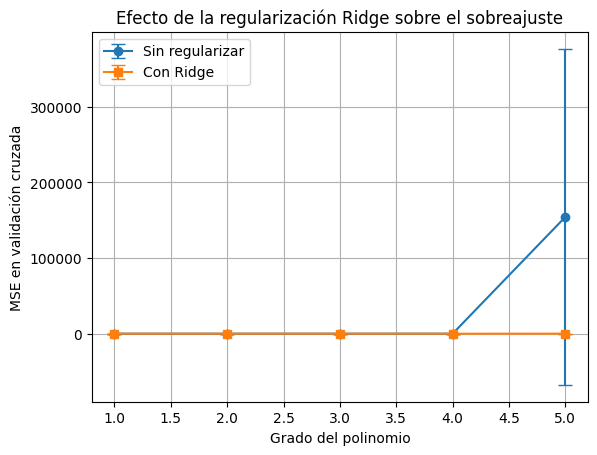

In [203]:
# Obtener resultados del GridSearch para Poly+Ridge
results_cv = pd.DataFrame(grid_poly_ridge.cv_results_)

# Filtrar por el mejor escalador (para simplificar, o agrupar por grado)
# Suponiendo que el mejor escalador es StandardScaler (por ejemplo)
best_scaler = grid_poly_ridge.best_params_['scaler']
mask = results_cv['param_scaler'] == best_scaler
filtered = results_cv[mask]

# Calcular media y std del MSE para cada grado (promediando sobre alphas)
grouped = filtered.groupby('param_poly__degree')['mean_test_score'].agg(['mean', 'std'])
grouped['mean_mse'] = -grouped['mean']
grouped['std_mse'] = grouped['std']

# Grados evaluados
degrees_ridge = grouped.index.astype(int)
degrees_unreg = list(range(1, len(means) + 1))

# Graficar junto con la curva del polinomio sin regularizar (obtenida antes)
plt.errorbar(degrees_unreg, means, yerr=stds, marker='o', label='Sin regularizar', capsize=5)
plt.errorbar(degrees_ridge, grouped['mean_mse'], yerr=grouped['std_mse'], marker='s', label='Con Ridge', capsize=5)
plt.xlabel('Grado del polinomio')
plt.ylabel('MSE en validación cruzada')
plt.title('Efecto de la regularización Ridge sobre el sobreajuste')
plt.legend()
plt.grid(True)
plt.show()

### Regresión polinomial regularizada (Polynomial + Ridge)

Se construyó un pipeline que combina generación de características polinomiales con regularización Ridge, optimizado mediante GridSearchCV. La búsqueda exploró el grado del polinomio (1–5), el parámetro de penalización (alpha en escala logarítmica) y distintas estrategias de escalamiento.

El mejor modelo obtenido presentó las siguientes métricas en el conjunto de prueba:

**RMSE:** 0.638

**MAE:** 0.337

**R²:** 0.9379

Además, en validación cruzada se obtuvo un RMSE cercano al observado en test, lo que sugiere buena estabilidad del modelo.

Al comparar con la regresión polinomial sin regularización, se observa que la incorporación de Ridge permite controlar mejor el crecimiento del error a medida que aumenta el grado del polinomio. Mientras que el modelo no regularizado mostraba un incremento del error de validación para grados mayores (indicando sobreajuste), el modelo regularizado presenta una curva más estable y con menor variabilidad.

Este comportamiento evidencia el papel de la regularización como mecanismo de control de complejidad. Al añadir términos polinomiales, el modelo incrementa su capacidad de ajuste y, por ende, el riesgo de sobreajuste. La penalización L2 actúa restringiendo la magnitud de los coeficientes, evitando que crezcan excesivamente y reduciendo la sensibilidad al ruido.

La comparación de curvas de validación confirma que la regularización suaviza la transición entre modelos simples y complejos. Aunque no elimina completamente el riesgo de sobreajuste, sí logra mitigarlo, permitiendo explorar grados polinomiales mayores con menor deterioro en la generalización.

En conclusión, la regularización Ridge resulta efectiva para controlar el sobreajuste en modelos polinomiales, especialmente cuando se incrementa la complejidad del modelo. Esto demuestra la utilidad de combinar expansión de características con penalización, logrando un equilibrio entre flexibilidad y capacidad de generalización.

## 7. Comparación y selección del mejor modelo

Se compararon cuatro modelos: regresión polinomial sin regularización, Ridge, Lasso y regresión polinomial regularizada (Poly+Ridge). La selección se realizó considerando tanto el desempeño promedio (RMSE) como la estabilidad observada en validación cruzada.

El modelo con mejor desempeño en el conjunto de prueba fue Poly+Ridge, con:

**RMSE:** 0.6384

**MAE:** 0.3370

**R²:** 0.9379

Aunque la mejora en RMSE respecto al modelo polinomial simple es moderada, resulta consistente. Más importante aún, el análisis de validación cruzada mostró que la incorporación de regularización permite controlar el incremento del error al aumentar el grado del polinomio, reduciendo la variabilidad entre folds y mitigando el sobreajuste.

El modelo polinomial sin regularización presenta un desempeño competitivo, pero evidencia mayor sensibilidad al incremento de complejidad. Por su parte, Ridge y Lasso lineales presentan alta estabilidad, aunque menor flexibilidad. Lasso ofrece además selección automática de características, pero sin mejora significativa en desempeño predictivo.

En términos de equilibrio entre desempeño, complejidad y estabilidad, el modelo Poly+Ridge representa la mejor elección. Combina la capacidad de modelar relaciones no lineales con el control de complejidad introducido por la penalización L2, logrando un mejor trade-off sesgo-varianza.

Por lo tanto, se selecciona el modelo Regresión Polinomial Regularizada (Poly+Ridge) como modelo final.

In [204]:
results = pd.DataFrame({
    "Modelo": ["Polinomial", "Ridge", "Lasso", "Poly+Ridge"],
    "RMSE": [rmse_poly, rmse_ridge, rmse_lasso, rmse_poly_ridge],
    "MAE": [mae_poly, mae_ridge, mae_lasso, mae_poly_ridge],
    "R2": [r2_poly, r2_ridge, r2_lasso, r2_poly_ridge]
})

results.sort_values("RMSE")

,Modelo,RMSE,MAE,R2
3,Poly+Ridge,0.638446,0.337037,0.937872
0,Polinomial,0.644229,0.279529,0.936741
1,Ridge,0.645238,0.289154,0.936543
2,Lasso,0.645867,0.286051,0.936419


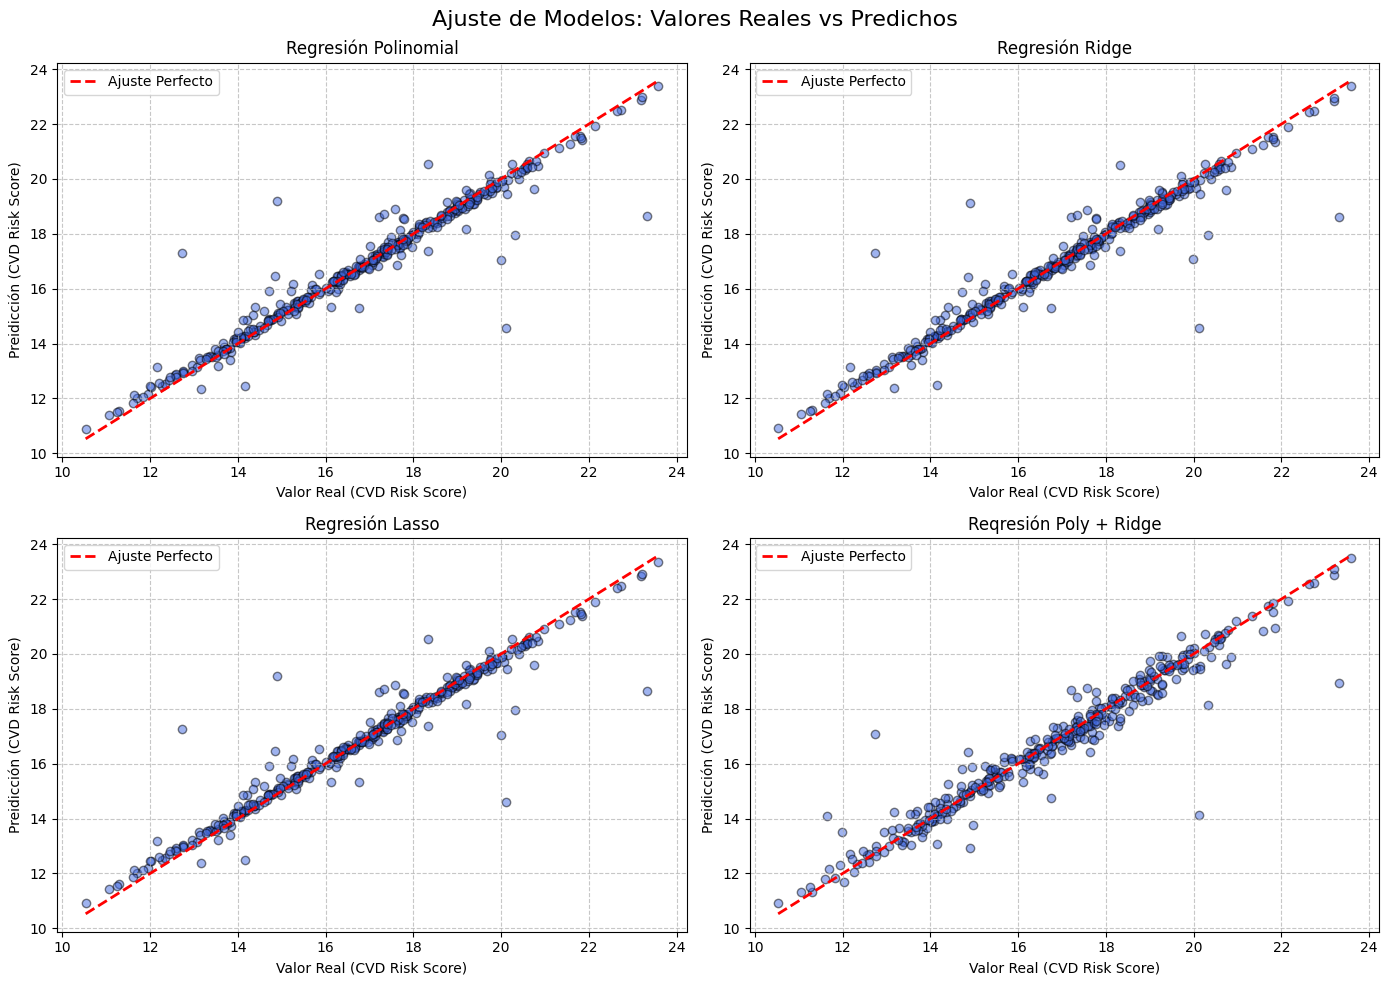

In [205]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Ajuste de Modelos: Valores Reales vs Predichos', fontsize=16)

# Diccionario con los modelos previamente entrenados
modelos = {
    'Regresión Polinomial': best_poly,
    'Regresión Ridge': best_ridge,
    'Regresión Lasso': best_lasso,
    'Reqresión Poly + Ridge': best_poly_ridge
}

for ax, (nombre, modelo) in zip(axes.flatten(), modelos.items()):
    # Generar predicciones
    predicciones = modelo.predict(X_test)

    # Gráfico de dispersión
    ax.scatter(y_test, predicciones, alpha=0.5, color='royalblue', edgecolor='k')

    # Línea base de ajuste perfecto (y_pred = y_test)
    min_val = min(y_test.min(), predicciones.min())
    max_val = max(y_test.max(), predicciones.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ajuste Perfecto')

    ax.set_title(nombre)
    ax.set_xlabel('Valor Real (CVD Risk Score)')
    ax.set_ylabel('Preidicción (CVD Risk Score)')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## 7. Intervalos de Confianza (Bootstrapping)

--- Resultados de Bootstrapping (1000 iteraciones) ---
RMSE : Media = 0.6286, IC 95%: [0.4477, 0.8199]
MAE  : Media = 0.3362, IC 95%: [0.2852, 0.3959]
R2   : Media = 0.9381, IC 95%: [0.8965, 0.9686]


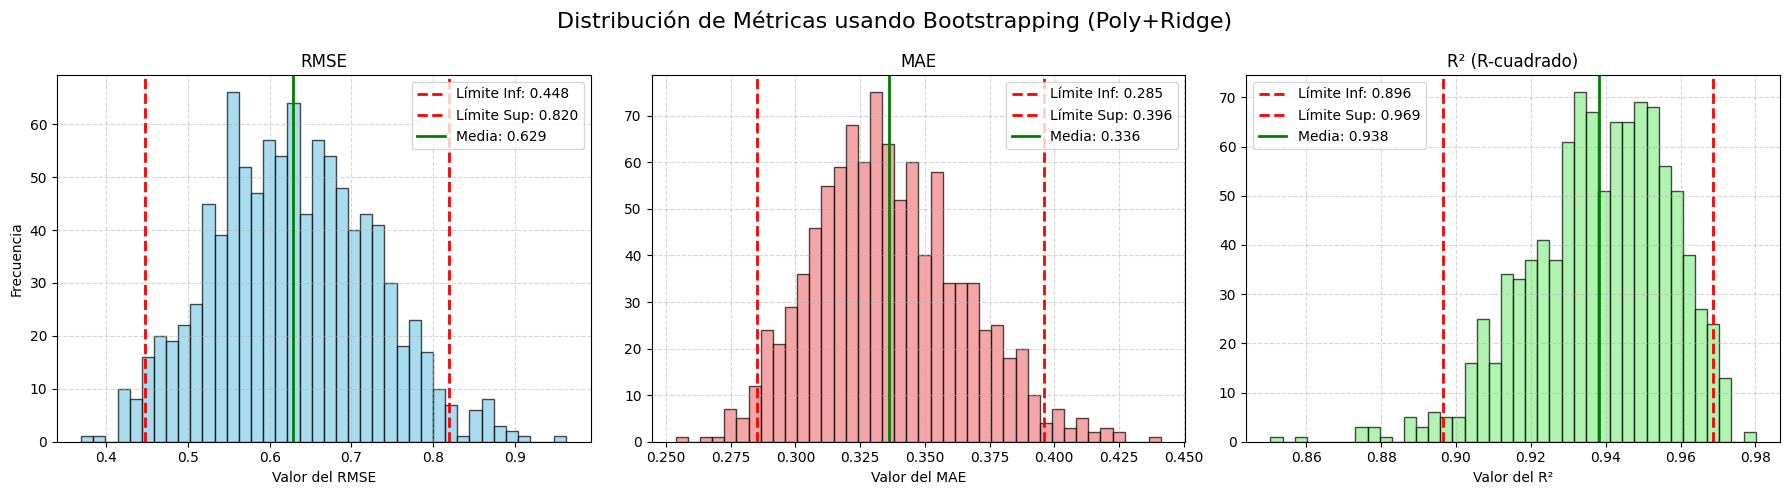

In [206]:
from sklearn.utils import resample

# 1. Seleccionar el mejor modelo, este fue el de Poly+Ridge
modelo_evaluar = best_poly_ridge

n_iterations = 1000
bootstrap_rmses = []
bootstrap_maes = []
bootstrap_r2s = []

for i in range(n_iterations):
    # Remuestreo del conjunto de prueba con reemplazo
    X_boot, y_boot = resample(X_test, y_test, random_state=i)

    # Predicción
    y_pred_boot = modelo_evaluar.predict(X_boot)

    # Cálculo de métricas
    bootstrap_rmses.append(np.sqrt(mean_squared_error(y_boot, y_pred_boot)))
    bootstrap_maes.append(mean_absolute_error(y_boot, y_pred_boot))
    bootstrap_r2s.append(r2_score(y_boot, y_pred_boot))

# 2. Calcular los percentiles para un intervalo de confianza del 95%
alpha = 0.95
p_inferior = ((1.0 - alpha) / 2.0) * 100        # 2.5%
p_superior = (alpha + ((1.0 - alpha) / 2.0)) * 100  # 97.5%

def calcular_ic(metricas):
    inferior = np.percentile(metricas, p_inferior)
    superior = np.percentile(metricas, p_superior)
    media = np.mean(metricas)
    return media, inferior, superior

media_rmse, inf_rmse, sup_rmse = calcular_ic(bootstrap_rmses)
media_mae, inf_mae, sup_mae = calcular_ic(bootstrap_maes)
media_r2, inf_r2, sup_r2 = calcular_ic(bootstrap_r2s)

print(f"--- Resultados de Bootstrapping ({n_iterations} iteraciones) ---")
print(f"RMSE : Media = {media_rmse:.4f}, IC 95%: [{inf_rmse:.4f}, {sup_rmse:.4f}]")
print(f"MAE  : Media = {media_mae:.4f}, IC 95%: [{inf_mae:.4f}, {sup_mae:.4f}]")
print(f"R2   : Media = {media_r2:.4f}, IC 95%: [{inf_r2:.4f}, {sup_r2:.4f}]")

# 3. Visualización de la distribución de los errores (RMSE, MAE, R2)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribución de Métricas usando Bootstrapping (Poly+Ridge)', fontsize=16)

# -- Gráfico 1: RMSE --
axes[0].hist(bootstrap_rmses, bins=40, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(inf_rmse, color='red', linestyle='dashed', linewidth=2, label=f'Límite Inf: {inf_rmse:.3f}')
axes[0].axvline(sup_rmse, color='red', linestyle='dashed', linewidth=2, label=f'Límite Sup: {sup_rmse:.3f}')
axes[0].axvline(media_rmse, color='green', linestyle='solid', linewidth=2, label=f'Media: {media_rmse:.3f}')
axes[0].set_title('RMSE')
axes[0].set_xlabel('Valor del RMSE')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# -- Gráfico 2: MAE --
axes[1].hist(bootstrap_maes, bins=40, color='lightcoral', edgecolor='black', alpha=0.7)
axes[1].axvline(inf_mae, color='red', linestyle='dashed', linewidth=2, label=f'Límite Inf: {inf_mae:.3f}')
axes[1].axvline(sup_mae, color='red', linestyle='dashed', linewidth=2, label=f'Límite Sup: {sup_mae:.3f}')
axes[1].axvline(media_mae, color='green', linestyle='solid', linewidth=2, label=f'Media: {media_mae:.3f}')
axes[1].set_title('MAE')
axes[1].set_xlabel('Valor del MAE')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

# -- Gráfico 3: R2 --
axes[2].hist(bootstrap_r2s, bins=40, color='lightgreen', edgecolor='black', alpha=0.7)
axes[2].axvline(inf_r2, color='red', linestyle='dashed', linewidth=2, label=f'Límite Inf: {inf_r2:.3f}')
axes[2].axvline(sup_r2, color='red', linestyle='dashed', linewidth=2, label=f'Límite Sup: {sup_r2:.3f}')
axes[2].axvline(media_r2, color='green', linestyle='solid', linewidth=2, label=f'Media: {media_r2:.3f}')
axes[2].set_title('R² (R-cuadrado)')
axes[2].set_xlabel('Valor del R²')
axes[2].legend()
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.subplots_adjust(top=0.85) # Ajusta el espacio para el titulo general
plt.show()

Estabilidad del modelo: Al realizar las pruebas de bootstrapping, se observa que el modelo Poly+Ridge muestra una variabilidad baja en $R^2, [0.8965, 0.9686]$, lo que indica que es un modelo estable y confiable para este conjunto de datos. Por otro lado, el modelo tiene un MAE de $[0.2852, 0.3959]$ lo que nos indica que el error promedio de las predicciones es relativamente bajo. Ya para terminar, el RMSE se encuentra en el rango de $[0.4477, 0.8199]$, lo que nos dice que con un 95% de confianza, el error cuadrático medio de las predicciones del modelo se encuentra dentro de este rango, lo que es un buen resultado para un modelo de regresión.

## 8. Análisis de Resultados

**Análisis cuantitatvo.**

- ¿Cuál modelo obtuvo el mejor desempeño en el conjunto de test?

- ¿Coincide el mejor desempeño en test con el mejor promedio en validación cruzada? Si no coincide, ¿cuál puede ser la explicación?

- ¿El modelo con mejor métrica promedio es necesariamente el más adecuado? Justifica considerando también la desviación estándar del desempeño.

- Con base en las curvas de validación, ¿cómo cambia el error a medida que aumenta la complejidad? ¿En qué punto se evidencia sobreajuste?

- ¿Cómo afecta la regularización la magnitud y estabilidad de los coeficientes?

- ¿Los intervalos de confianza obtenidos mediante bootstrapping sugieren estabilidad o alta variabilidad en el desempeño? ¿Qué implicaciones tiene esto?

**Análisis cualitativo.**

- ¿Qué variables fueron seleccionadas como más relevantes por el modelo Lasso?

- ¿Qué interpretación práctica tienen los coeficientes del modelo final en el contexto del riesgo cardiovascular?

- ¿Existen diferencias relevantes entre el modelo más preciso y el más interpretable?

- ¿Qué decisiones estratégicas podría tomar AlpesHearth a partir de los resultados obtenidos?

- ¿Mayor precisión implica necesariamente mayor valor para la organización? 

- ¿Un modelo más complejo necesariamente genera mayor valor empresarial? Discute considerando interpretabilidad, estabilidad y costo de implementación.

**Reflexión conceptual.**

- ¿Qué relación observas entre complejidad del modelo, capacidad de generalización y estabilidad del desempeño?

- ¿Qué fuentes de sesgo podrían estar presentes en los datos o en el proceso de modelado?

- Si el tamaño de muestra fuera mayor, ¿esperarías cambios en la estabilidad de los modelos? Explique.


## 9. Uso de Herramientas de IA Generativa

**Herramienta utilizada:** ChatGPT  

**Tipo de uso:**  
- Apoyo conceptual  
- Generación inicial de estructura  
- Explicación de regularización y bootstrapping  

**Prompts utilizados:**  
- "Explícame la diferencia entre Ridge y Lasso"  
- "Cómo implementar bootstrapping en sklearn"  

**Análisis crítico y aportes propios:**  
(Completar por los estudiantes)
